# Gold Multi-Factor Dashboard
Live, self-updating tracker for the 10 drivers of gold covered in your script:
CPI/inflation expectations, geopolitical risk, real yields, DXY correlation,
central-bank buying/de-dollarization, COT positioning, gold ETF flows,
gold/silver ratio, seasonality, and a consolidated read.

**How to use it:** just re-run the whole notebook (Run All) any time you want a
fresh reading — every section pulls live data at run time, nothing is
hard-coded. The last cell is a rule-based "AI agent" that reads everything
above and gives you a plain-English summary + a gameplan for the session.

**Data sources used (all free):**
- FRED (St. Louis Fed) — CPI, breakeven inflation, 10y real yields
- Yahoo Finance (`yfinance`) — Gold, Silver, DXY, VIX prices
- CFTC public Socrata API — Commitments of Traders (COT) report
- SPDR (State Street) — GLD ETF daily holdings (a live proxy for gold ETF flows)
- IMF COFER — USD share of global FX reserves (central-bank de-dollarization)
- Caldara–Iacoviello Geopolitical Risk (GPR) index, with a VIX fallback if that
  site is unreachable
- Gold's own price history — used to compute seasonality directly (no third
  -party seasonality provider needed)

> Note: a few of these sources (IMF, GPR site, SPDR, CFTC) occasionally change
> their file layout or rate-limit requests. Every section below is wrapped in
> error handling, so if one source is temporarily down you'll get a `[WARN]`
> message instead of a crash, and the rest of the notebook keeps running.
>
> Also normal: each section's "as of" date is the **latest date that source
> has actually published**, not necessarily today. Treasury/real-yield data
> lags by ~1 business day and skips weekends/holidays, COT is a weekly report
> (dated the prior Tuesday), and COFER is quarterly — so seeing "as of" a few
> days or weeks back is expected, not a bug.


In [1]:
# One-time / every-run dependency check (safe to re-run; only installs what's missing)
import importlib
import subprocess
import sys

_pkgs = {
    "fredapi": "fredapi",
    "yfinance": "yfinance",
    "pandas": "pandas",
    "numpy": "numpy",
    "matplotlib": "matplotlib",
    "requests": "requests",
    "openpyxl": "openpyxl",
}
_missing = [pip_name for mod_name, pip_name in _pkgs.items()
            if importlib.util.find_spec(mod_name) is None]

if _missing:
    print(f"Installing missing packages: {_missing}")
    try:
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", *_missing], check=True)
    except Exception as e:
        print(f"[WARN] Automatic install failed ({e}). "
              f"Run this manually in a terminal: pip install {' '.join(_missing)}")
else:
    print("All required packages already installed.")


All required packages already installed.


In [2]:
import warnings
warnings.filterwarnings("ignore")

import datetime as dt
from io import StringIO

import numpy as np
import pandas as pd
import requests
import matplotlib.pyplot as plt

try:
    import yfinance as yf
except ImportError:
    yf = None

try:
    from fredapi import Fred
except ImportError:
    Fred = None

# ---------------- CONFIG ----------------
FRED_API_KEY = "f4cc710ee914042b0631cfbd3a4a6c7d"   # your FRED key

TODAY = dt.date.today()
print(f"Notebook run date: {TODAY.isoformat()}")

fred = None
if Fred is not None and FRED_API_KEY:
    try:
        fred = Fred(api_key=FRED_API_KEY)
    except Exception as e:
        print(f"[WARN] Could not initialize FRED client: {e}")

# Every section below writes its results into this single dict.
# The final cell (the "AI agent") reads ONLY from this dict, so it always
# summarizes whatever actually came through on this run.
DASH = {}

def safe_call(label, func, *args, **kwargs):
    """Run func and catch/report any error so one dead data source never
    breaks the rest of the notebook."""
    try:
        return func(*args, **kwargs)
    except Exception as e:
        print(f"[WARN] {label} failed: {type(e).__name__}: {e}")
        return None

def get_close(df):
    """Return a clean 1-D Series of Close prices from a yfinance download,
    regardless of whether yfinance gave back flat columns or a MultiIndex
    (which newer yfinance versions sometimes do even for a single ticker)."""
    if df is None or df.empty:
        return None
    close = df["Close"]
    if isinstance(close, pd.DataFrame):
        close = close.iloc[:, 0]
    return close.dropna()


Notebook run date: 2026-09-08


## 1. CPI & Inflation Expectations

CPI_YoY_headline: latest = 3.54  (as of 2026-07-01)
CPI_YoY_core: latest = 2.79  (as of 2026-07-01)
Breakeven_10Y: latest = 2.35  (as of 2026-09-04)
Breakeven_5Y: latest = 2.37  (as of 2026-09-04)
Forward_5Y5Y_Inflation: latest = 2.33  (as of 2026-09-04)


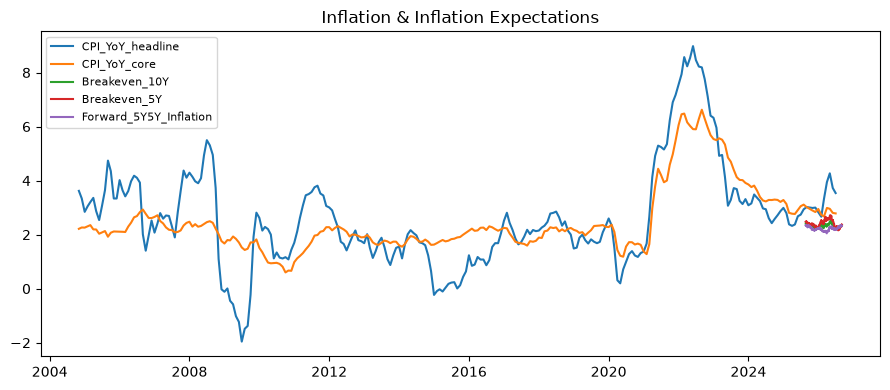

In [3]:
def get_cpi_inflation():
    out = {}
    if fred is None:
        print("FRED client not available - skipping.")
        return out
    series_map = {
        "CPI_YoY_headline": "CPIAUCSL",
        "CPI_YoY_core": "CPILFESL",
        "Breakeven_10Y": "T10YIE",
        "Breakeven_5Y": "T5YIE",
        "Forward_5Y5Y_Inflation": "T5YIFR",
    }
    for name, code_ in series_map.items():
        s = safe_call(f"FRED {code_}", fred.get_series, code_)
        if s is None or s.empty:
            continue
        s = s.dropna()
        if name.startswith("CPI"):
            yoy = (s.pct_change(12) * 100).dropna()
            out[name] = yoy
        else:
            out[name] = s
    return out

cpi_data = get_cpi_inflation()
for k, s in cpi_data.items():
    print(f"{k}: latest = {s.iloc[-1]:.2f}  (as of {s.index[-1].date()})")

DASH["inflation"] = {
    k: (float(s.iloc[-1]), s.index[-1].date().isoformat(),
        float(s.iloc[-1] - s.iloc[-2]) if len(s) > 1 else None)
    for k, s in cpi_data.items()
}

if cpi_data:
    fig, ax = plt.subplots(figsize=(9, 4))
    for k, s in cpi_data.items():
        ax.plot(s.index[-260:], s.values[-260:], label=k)
    ax.set_title("Inflation & Inflation Expectations")
    ax.legend(fontsize=8)
    plt.tight_layout()
    plt.show()
else:
    print("No inflation data available this run.")


## 2. Geopolitical Risk Premium

[WARN] Could not reach the Caldara-Iacoviello GPR index (matteoiacoviello.com/gpr.htm). Falling back to VIX as a live risk-appetite proxy.
VIX latest close: 15.30


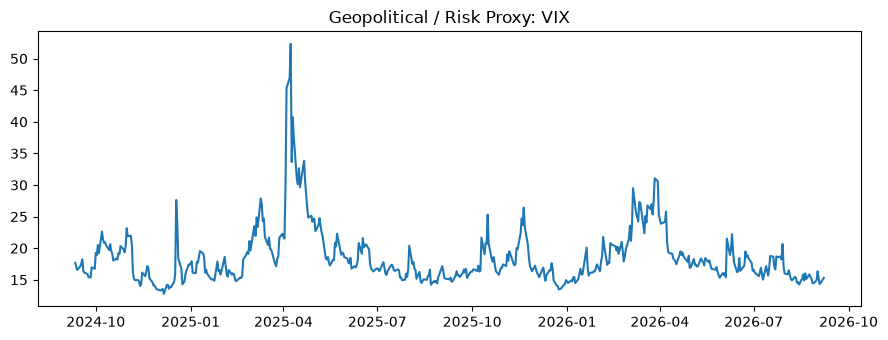

In [4]:
def get_geopolitical_risk():
    out = {}
    candidate_urls = [
        "https://www.matteoiacoviello.com/gpr_files/data_gpr_export.xls",
        "https://www.matteoiacoviello.com/gpr_files/data_gpr_daily_recent.xls",
    ]
    gpr = None
    used_url = None
    for url in candidate_urls:
        try:
            df = pd.read_excel(url)
            gpr = df
            used_url = url
            break
        except Exception:
            continue

    if gpr is not None:
        try:
            date_col = [c for c in gpr.columns
                        if any(tok in str(c).lower() for tok in ("date", "month", "time", "period"))][0]
            exact_matches = [c for c in gpr.columns if str(c).strip().upper() == "GPR"]
            val_col = exact_matches[0] if exact_matches else                 [c for c in gpr.columns if "gpr" in str(c).lower()][0]
            gpr[date_col] = pd.to_datetime(gpr[date_col])
            s = gpr.set_index(date_col)[val_col].dropna()
            out["series"] = s
            out["source_url"] = used_url
            print(f"Geopolitical Risk (GPR) index loaded from {used_url}")
            print(f"Latest GPR reading: {s.iloc[-1]:.1f} ({s.index[-1].date()})")
        except Exception as e:
            print(f"[WARN] GPR file fetched but could not be parsed: {e}")

    if "series" not in out:
        print("[WARN] Could not reach the Caldara-Iacoviello GPR index "
              "(matteoiacoviello.com/gpr.htm). Falling back to VIX as a "
              "live risk-appetite proxy.")
        if yf is not None:
            vix = safe_call("VIX (yfinance)", yf.download, "^VIX", period="2y",
                             progress=False, auto_adjust=True)
            vix_close = get_close(vix)
            if vix_close is not None and not vix_close.empty:
                out["proxy_series"] = vix_close
                out["proxy_name"] = "VIX"
                print(f"VIX latest close: {float(vix_close.iloc[-1]):.2f}")
    return out

geo_data = get_geopolitical_risk()
series = geo_data.get("series", geo_data.get("proxy_series"))
name = "GPR Index" if "series" in geo_data else geo_data.get("proxy_name", "Risk proxy")

if series is not None and len(series) > 0:
    fig, ax = plt.subplots(figsize=(9, 3.5))
    ax.plot(series.index[-500:], series.values[-500:])
    ax.set_title(f"Geopolitical / Risk Proxy: {name}")
    plt.tight_layout()
    plt.show()
    latest = float(series.iloc[-1])
    hist_mean = float(series.mean())
    DASH["geopolitical"] = {
        "name": name,
        "latest": latest,
        "historical_mean": hist_mean,
        "as_of": str(series.index[-1]),
    }
else:
    print("No geopolitical risk data available this run.")
    DASH["geopolitical"] = {}


## 3. Real Yields (opportunity cost of holding gold)

10Y TIPS real yield: 2.42% (as of 2026-09-03)


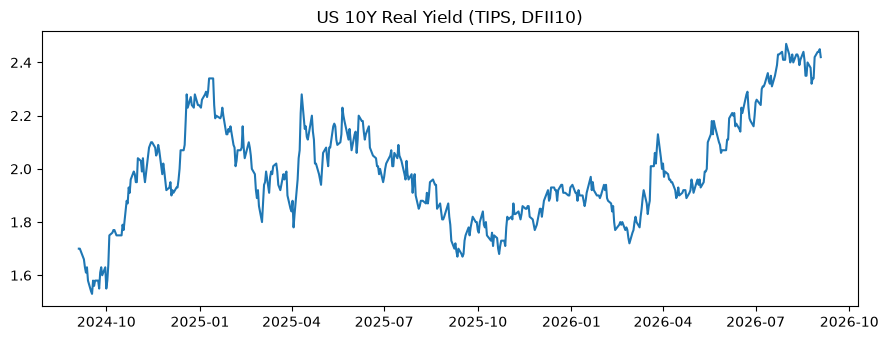

In [5]:
def get_real_yields():
    out = {}
    if fred is None:
        return out
    s = safe_call("FRED DFII10", fred.get_series, "DFII10")
    if s is not None:
        s = s.dropna()
        out["DFII10"] = s
        print(f"10Y TIPS real yield: {s.iloc[-1]:.2f}% (as of {s.index[-1].date()})")
    return out

real_yield_data = get_real_yields()
if "DFII10" in real_yield_data:
    s = real_yield_data["DFII10"]
    fig, ax = plt.subplots(figsize=(9, 3.5))
    ax.plot(s.index[-500:], s.values[-500:])
    ax.set_title("US 10Y Real Yield (TIPS, DFII10)")
    plt.tight_layout()
    plt.show()
    DASH["real_yields"] = {
        "DFII10_latest": float(s.iloc[-1]),
        "as_of": s.index[-1].date().isoformat(),
        "chg_1m": float(s.iloc[-1] - s.iloc[-22]) if len(s) > 22 else None,
    }
else:
    print("No real yield data available this run.")
    DASH["real_yields"] = {}


## 4. Dollar Index (DXY) Correlation

Gold vs DXY 60-day rolling return correlation: -0.54


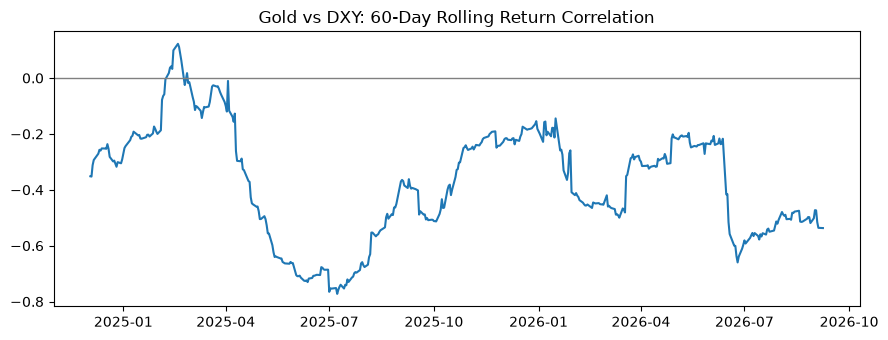

In [6]:
def get_dxy_gold_correlation():
    out = {}
    if yf is None:
        return out
    tickers = {"gold": "GC=F", "dxy": "DX-Y.NYB"}
    data = {}
    for name, tk in tickers.items():
        d = safe_call(f"yfinance {tk}", yf.download, tk, period="2y",
                       progress=False, auto_adjust=True)
        c = get_close(d)
        if c is not None and not c.empty:
            data[name] = c
    if len(data) == 2:
        df = pd.concat(data, axis=1).dropna()
        df.columns = ["gold", "dxy"]
        rolling_corr = df["gold"].pct_change().rolling(60).corr(df["dxy"].pct_change()).dropna()
        out["df"] = df
        out["rolling_corr"] = rolling_corr
        print(f"Gold vs DXY 60-day rolling return correlation: {float(rolling_corr.iloc[-1]):.2f}")
    return out

dxy_data = get_dxy_gold_correlation()
if "rolling_corr" in dxy_data:
    rc = dxy_data["rolling_corr"]
    fig, ax = plt.subplots(figsize=(9, 3.5))
    ax.plot(rc.index, rc.values)
    ax.axhline(0, color="grey", lw=1)
    ax.set_title("Gold vs DXY: 60-Day Rolling Return Correlation")
    plt.tight_layout()
    plt.show()
    DASH["dxy_correlation"] = {
        "latest_60d_corr": float(rc.iloc[-1]),
        "as_of": str(rc.index[-1]),
    }
else:
    print("No DXY correlation data available this run.")
    DASH["dxy_correlation"] = {}


## 5. Central Bank Buying & De-Dollarization (IMF COFER)

[WARN] IMF SDMX 2.1 COFER fetch failed: JSONDecodeError: Expecting value: line 1 column 1 (char 0)
USD share of global FX reserves (IMF COFER, SDMX 3.0 live): 57.1% (2026-01-01)


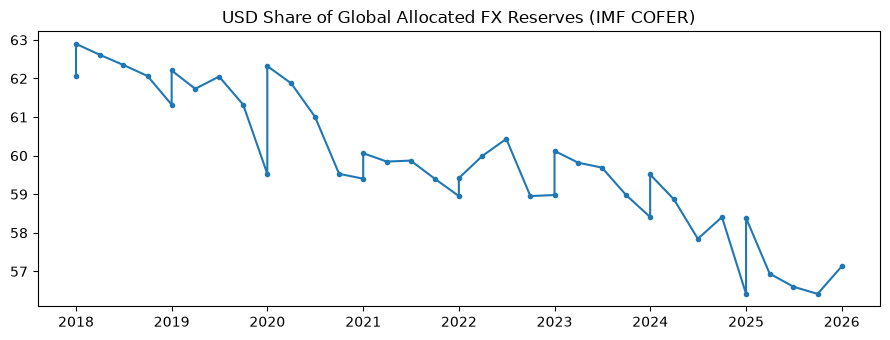

In [7]:
def parse_sdmx_json(payload):
    """Generic parser for the standard SDMX-JSON 1.0 data message format
    (used by IMF's SDMX 2.1 REST API, and by many other SDMX providers).
    Returns a long-format DataFrame with one row per (dimensions, time, value)."""
    ds = payload["data"]["dataSets"][0]
    series_dims = payload["data"]["structure"]["dimensions"]["series"]
    obs_dims = payload["data"]["structure"]["dimensions"]["observation"]
    time_values = obs_dims[0]["values"]
    records = []
    for series_key, series_obj in ds.get("series", {}).items():
        idxs = [int(x) for x in series_key.split(":")]
        dim_labels = {d["id"]: d["values"][i]["id"] for d, i in zip(series_dims, idxs)}
        for obs_idx, obs_val in series_obj.get("observations", {}).items():
            time_id = time_values[int(obs_idx)]["id"]
            val = obs_val[0] if isinstance(obs_val, list) else obs_val
            rec = dict(dim_labels)
            rec["TIME_PERIOD"] = time_id
            rec["OBS_VALUE"] = val
            records.append(rec)
    return pd.DataFrame(records)


def extract_world_usd_share(df):
    """Given a long-format dataframe with arbitrary dimension columns plus
    TIME_PERIOD/OBS_VALUE, flexibly find the 'World, USD, share-of-total'
    series without assuming exact column names or code values."""
    if df is None or df.empty:
        return None
    dim_cols = [c for c in df.columns if c not in ("TIME_PERIOD", "OBS_VALUE")]
    world_mask = df[dim_cols].apply(
        lambda row: any(str(v).upper() in ("W00", "WORLD", "W0", "G001") for v in row), axis=1)
    usd_mask = df[dim_cols].apply(lambda row: any("usd" in str(v).lower() for v in row), axis=1)
    share_mask = df[dim_cols].apply(
        lambda row: any(tok in str(v).lower() for v in row for tok in ("shr", "share", "_pt")), axis=1)
    sub = df[world_mask & usd_mask & share_mask]
    if sub.empty:
        return None
    sub = sub.sort_values("TIME_PERIOD")
    try:
        idx = pd.PeriodIndex(sub["TIME_PERIOD"].astype(str), freq="Q").to_timestamp()
    except Exception:
        idx = pd.to_datetime(sub["TIME_PERIOD"].astype(str), errors="coerce")
    s = pd.Series(pd.to_numeric(sub["OBS_VALUE"], errors="coerce").values, index=idx).dropna()
    return s if not s.empty else None


def get_cofer_usd_share():
    out = {}

    # --- Attempt 1: IMF's SDMX 2.1 REST API at api.imf.org (documented,
    # standardized SDMX-JSON response format - the most reliable of the
    # options below since it follows a public, versioned spec rather than
    # an ad-hoc shape). "all"/"all" wildcards key and provider per IMF's docs.
    try:
        url = "https://api.imf.org/external/sdmx/2.1/data/IMF.STA,COFER,latest/all/all"
        r = requests.get(url, params={"startPeriod": "2018"},
                          headers={"Accept": "application/vnd.sdmx.data+json;version=1.0.0"},
                          timeout=25)
        r.raise_for_status()
        df = parse_sdmx_json(r.json())
        s = extract_world_usd_share(df)
        if s is not None:
            out["usd_share"] = s
            print(f"USD share of global FX reserves (IMF COFER, SDMX 2.1 live): "
                  f"{s.iloc[-1]:.1f}% ({s.index[-1].date()})")
    except Exception as e:
        print(f"[WARN] IMF SDMX 2.1 COFER fetch failed: {type(e).__name__}: {e}")

    # --- Attempt 2: newer api.imf.org SDMX 3.0 CSV endpoint, as a second try ---
    if "usd_share" not in out:
        try:
            url = "https://api.imf.org/external/sdmx/3.0/data/dataflow/IMF.STA/COFER/~/*"
            r = requests.get(url, params={"c[TIME_PERIOD]": "ge:2018-01"},
                              headers={"Accept": "text/csv"}, timeout=25)
            r.raise_for_status()
            df = pd.read_csv(StringIO(r.text), low_memory=False)
            cols_lower = {c.lower(): c for c in df.columns}
            time_col = next((cols_lower[c] for c in cols_lower if "time_period" in c or c == "period"), None)
            val_col = next((cols_lower[c] for c in cols_lower if "obs_value" in c or c == "value"), None)
            if time_col and val_col:
                df = df.rename(columns={time_col: "TIME_PERIOD", val_col: "OBS_VALUE"})
                s = extract_world_usd_share(df)
                if s is not None:
                    out["usd_share"] = s
                    print(f"USD share of global FX reserves (IMF COFER, SDMX 3.0 live): "
                          f"{s.iloc[-1]:.1f}% ({s.index[-1].date()})")
        except Exception as e:
            print(f"[WARN] IMF SDMX 3.0 COFER fetch failed: {type(e).__name__}: {e}")

    if "usd_share" not in out:
        # --- Manual fallback ---
        # IMF's COFER API has moved/changed shape several times in 2025-2026.
        # COFER is only published quarterly, so updating this by hand each
        # quarter is normal, not a workaround. Source:
        #   https://data.imf.org/en/datasets/IMF.STA:COFER
        MANUAL_COFER_USD_SHARE_PCT = 57.80   # <- update each quarter
        MANUAL_COFER_AS_OF = "2024-Q4"       # <- update each quarter
        print(f"[INFO] Live IMF fetch unavailable - using manual fallback: "
              f"USD reserve share = {MANUAL_COFER_USD_SHARE_PCT}% as of {MANUAL_COFER_AS_OF}. "
              "Update MANUAL_COFER_USD_SHARE_PCT / MANUAL_COFER_AS_OF in this cell each "
              "quarter from https://data.imf.org/en/datasets/IMF.STA:COFER")
        out["usd_share_manual"] = MANUAL_COFER_USD_SHARE_PCT
        out["usd_share_manual_as_of"] = MANUAL_COFER_AS_OF

    return out

cofer_data = get_cofer_usd_share()
if "usd_share" in cofer_data:
    s = cofer_data["usd_share"]
    fig, ax = plt.subplots(figsize=(9, 3.5))
    ax.plot(s.index, s.values, marker="o", ms=3)
    ax.set_title("USD Share of Global Allocated FX Reserves (IMF COFER)")
    plt.tight_layout()
    plt.show()
    DASH["central_bank_dedollarization"] = {
        "usd_share_latest": float(s.iloc[-1]),
        "as_of": s.index[-1].date().isoformat(),
        "chg_yoy": float(s.iloc[-1] - s.iloc[-5]) if len(s) > 4 else None,
        "source": "live",
    }
elif "usd_share_manual" in cofer_data:
    DASH["central_bank_dedollarization"] = {
        "usd_share_latest": cofer_data["usd_share_manual"],
        "as_of": cofer_data["usd_share_manual_as_of"],
        "chg_yoy": None,
        "source": "manual fallback - update quarterly, see [INFO] note above",
    }
else:
    print("No IMF COFER data available this run.")
    DASH["central_bank_dedollarization"] = {}


## 6. COT Report (Commitment of Traders)

COT (as of 2026-09-01): Managed-money net long = 228,124 contracts, Open interest = 415,196


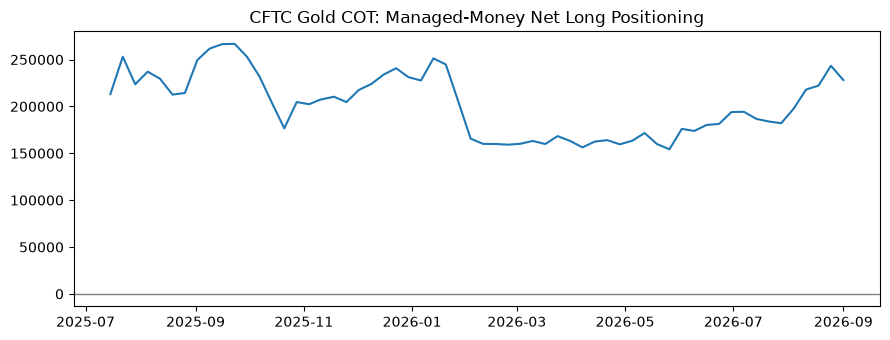

In [8]:
def get_cot_gold():
    out = {}
    url = "https://publicreporting.cftc.gov/resource/6dca-aqww.json"
    params = {
        "$where": "market_and_exchange_names like 'GOLD - COMMODITY EXCHANGE INC.'",
        "$order": "report_date_as_yyyy_mm_dd DESC",
        "$limit": 60,
    }
    try:
        r = requests.get(url, params=params, timeout=20)
        r.raise_for_status()
        rows = r.json()
        if not rows:
            print("[WARN] CFTC COT query returned no rows for gold.")
            return out
        df = pd.DataFrame(rows)
        df["report_date_as_yyyy_mm_dd"] = pd.to_datetime(df["report_date_as_yyyy_mm_dd"])
        df = df.sort_values("report_date_as_yyyy_mm_dd")
        for c in ["noncomm_positions_long_all", "noncomm_positions_short_all",
                  "comm_positions_long_all", "comm_positions_short_all",
                  "open_interest_all"]:
            if c in df.columns:
                df[c] = pd.to_numeric(df[c], errors="coerce")
        df["managed_money_net"] = df["noncomm_positions_long_all"] - df["noncomm_positions_short_all"]
        out["df"] = df.set_index("report_date_as_yyyy_mm_dd")
        latest = out["df"].iloc[-1]
        print(f"COT (as of {out['df'].index[-1].date()}): "
              f"Managed-money net long = {latest['managed_money_net']:,.0f} contracts, "
              f"Open interest = {latest['open_interest_all']:,.0f}")
    except Exception as e:
        print(f"[WARN] CFTC COT fetch failed: {type(e).__name__}: {e}")
    return out

cot_data = get_cot_gold()
if "df" in cot_data:
    df = cot_data["df"]
    fig, ax = plt.subplots(figsize=(9, 3.5))
    ax.plot(df.index, df["managed_money_net"])
    ax.axhline(0, color="grey", lw=1)
    ax.set_title("CFTC Gold COT: Managed-Money Net Long Positioning")
    plt.tight_layout()
    plt.show()
    z = (df["managed_money_net"].iloc[-1] - df["managed_money_net"].mean()) / df["managed_money_net"].std()
    DASH["cot"] = {
        "managed_money_net_latest": float(df["managed_money_net"].iloc[-1]),
        "as_of": df.index[-1].date().isoformat(),
        "chg_1w": float(df["managed_money_net"].iloc[-1] - df["managed_money_net"].iloc[-2]) if len(df) > 1 else None,
        "zscore_1yr": float(z),
    }
else:
    print("No COT data available this run.")
    DASH["cot"] = {}


## 7. Gold ETF Flows (SPDR GLD holdings, as a live flow proxy)

In [9]:
def get_gld_holdings():
    out = {}
    url = "https://www.spdrgoldshares.com/assets/dynamic/GLD/GLD_US_archive_EN.csv"
    try:
        r = requests.get(url, timeout=20, headers={"User-Agent": "Mozilla/5.0"})
        r.raise_for_status()
        raw_lines = r.text.splitlines()
        # Require the line to both start with "Date" AND look like a real
        # multi-column CSV header (several commas) - some versions of this
        # file have an earlier "Date of last update: ..." disclaimer line
        # that also starts with "Date" but has no commas, which would
        # otherwise get picked by mistake.
        header_idx = next(
            (i for i, ln in enumerate(raw_lines)
             if ln.strip().startswith("Date") and ln.count(",") >= 3),
            None,
        )
        if header_idx is None:
            raise ValueError("Could not find a CSV header row starting with 'Date' "
                              "that has multiple columns - the file layout may have changed.")
        df = pd.read_csv(StringIO(r.text), skiprows=header_idx, on_bad_lines="skip", engine="python")
        df.columns = [c.strip() for c in df.columns]
        date_col = df.columns[0]
        tonnes_col = [c for c in df.columns if "Tonnes" in c][0]
        df[date_col] = pd.to_datetime(df[date_col], errors="coerce")
        df = df.dropna(subset=[date_col]).set_index(date_col)
        s = pd.to_numeric(df[tonnes_col], errors="coerce").dropna()
        out["tonnes"] = s
        print(f"GLD holdings: {s.iloc[-1]:,.1f} tonnes (as of {s.index[-1].date()})")
    except Exception as e:
        print(f"[WARN] SPDR GLD holdings fetch failed: {type(e).__name__}: {e}")
    return out

gld_data = get_gld_holdings()
if "tonnes" in gld_data:
    s = gld_data["tonnes"]
    fig, ax = plt.subplots(figsize=(9, 3.5))
    ax.plot(s.index[-260:], s.values[-260:])
    ax.set_title("SPDR Gold Shares (GLD) Holdings, Tonnes")
    plt.tight_layout()
    plt.show()
    DASH["etf_flows"] = {
        "gld_tonnes_latest": float(s.iloc[-1]),
        "as_of": s.index[-1].date().isoformat(),
        "chg_1w": float(s.iloc[-1] - s.iloc[-6]) if len(s) > 5 else None,
        "chg_1m": float(s.iloc[-1] - s.iloc[-22]) if len(s) > 21 else None,
    }
else:
    print("No GLD ETF flow data available this run.")
    DASH["etf_flows"] = {}


[WARN] SPDR GLD holdings fetch failed: ValueError: Could not find a CSV header row starting with 'Date' that has multiple columns - the file layout may have changed.
No GLD ETF flow data available this run.


## 8. Gold / Silver Ratio

Gold/Silver ratio: 66.7 (as of 2026-09-08)


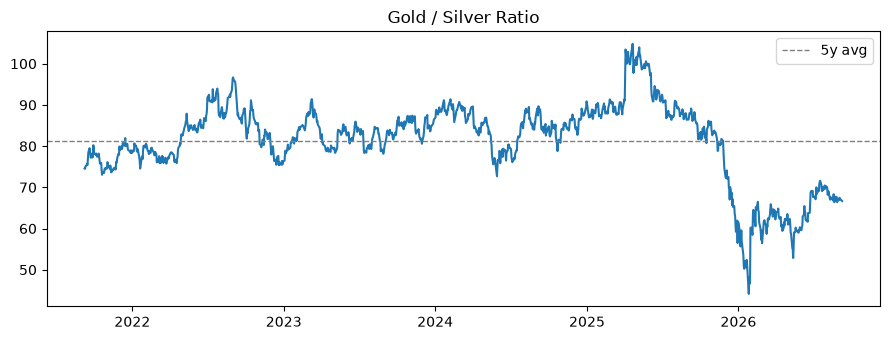

In [10]:
def get_gold_silver_ratio():
    out = {}
    if yf is None:
        return out
    gold = safe_call("yfinance GC=F", yf.download, "GC=F", period="5y", progress=False, auto_adjust=True)
    silver = safe_call("yfinance SI=F", yf.download, "SI=F", period="5y", progress=False, auto_adjust=True)
    gold_c, silver_c = get_close(gold), get_close(silver)
    if gold_c is not None and silver_c is not None and not gold_c.empty and not silver_c.empty:
        df = pd.concat([gold_c, silver_c], axis=1).dropna()
        df.columns = ["gold", "silver"]
        df["ratio"] = df["gold"] / df["silver"]
        out["df"] = df
        print(f"Gold/Silver ratio: {df['ratio'].iloc[-1]:.1f} (as of {df.index[-1].date()})")
    return out

gs_data = get_gold_silver_ratio()
if "df" in gs_data:
    df = gs_data["df"]
    fig, ax = plt.subplots(figsize=(9, 3.5))
    ax.plot(df.index, df["ratio"])
    ax.axhline(df["ratio"].mean(), color="grey", ls="--", lw=1, label="5y avg")
    ax.set_title("Gold / Silver Ratio")
    ax.legend()
    plt.tight_layout()
    plt.show()
    DASH["gold_silver_ratio"] = {
        "latest": float(df["ratio"].iloc[-1]),
        "as_of": df.index[-1].date().isoformat(),
        "avg_5y": float(df["ratio"].mean()),
        "pctile_5y": float((df["ratio"] < df["ratio"].iloc[-1]).mean() * 100),
    }
else:
    print("No gold/silver ratio data available this run.")
    DASH["gold_silver_ratio"] = {}


## 9. Seasonality Patterns (computed directly from gold's own price history)

Average monthly return by calendar month (all available history):
  Month 01: +3.00%
  Month 02: +1.19%
  Month 03: +0.28%
  Month 04: +1.21%
  Month 05: +0.28%
  Month 06: -0.90%
  Month 07: +0.97%
  Month 08: +2.30%
  Month 09: +0.75%
  Month 10: +0.21%
  Month 11: +1.36%
  Month 12: +1.41%


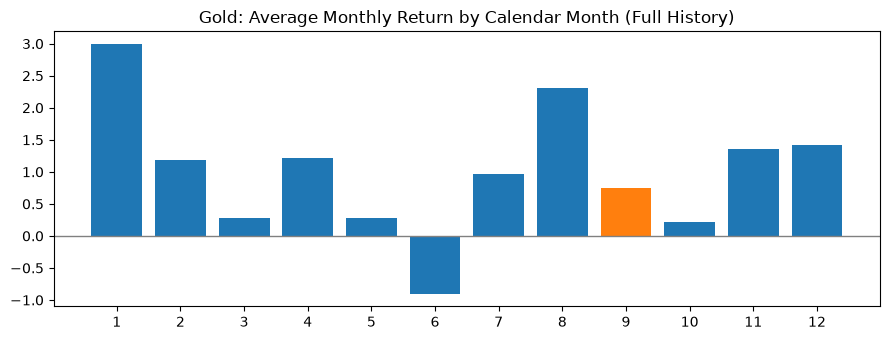

In [11]:
def get_gold_seasonality():
    out = {}
    if yf is None:
        return out
    hist = safe_call("yfinance GC=F history", yf.download, "GC=F", period="max",
                      progress=False, auto_adjust=True)
    px = get_close(hist)
    if px is None or px.empty:
        return out
    monthly = px.resample("ME").last()
    monthly_ret = monthly.pct_change().dropna().to_frame("ret")
    monthly_ret["month"] = monthly_ret.index.month
    seasonality = monthly_ret.groupby("month")["ret"].mean() * 100
    out["seasonality"] = seasonality
    out["current_month"] = dt.date.today().month
    print("Average monthly return by calendar month (all available history):")
    for m, v in seasonality.items():
        print(f"  Month {m:02d}: {v:+.2f}%")
    return out

season_data = get_gold_seasonality()
if "seasonality" in season_data:
    s = season_data["seasonality"]
    fig, ax = plt.subplots(figsize=(9, 3.5))
    colors = ["tab:orange" if m == season_data["current_month"] else "tab:blue" for m in s.index]
    ax.bar(s.index, s.values, color=colors)
    ax.set_xticks(range(1, 13))
    ax.axhline(0, color="grey", lw=1)
    ax.set_title("Gold: Average Monthly Return by Calendar Month (Full History)")
    plt.tight_layout()
    plt.show()
    cur_m = season_data["current_month"]
    DASH["seasonality"] = {
        "current_month": cur_m,
        "avg_return_this_month_pct": float(s.get(cur_m, np.nan)),
        "best_month": int(s.idxmax()),
        "best_month_avg_pct": float(s.max()),
        "worst_month": int(s.idxmin()),
        "worst_month_avg_pct": float(s.min()),
    }
else:
    print("No seasonality data available this run.")
    DASH["seasonality"] = {}


## 10. Consolidated Dashboard

In [12]:
print(f"=== GOLD MULTI-FACTOR DASHBOARD (as of {dt.date.today().isoformat()}) ===\n")
for section, vals in DASH.items():
    print(f"--- {section} ---")
    if not vals:
        print("  (no data available this run)")
    else:
        for k, v in vals.items():
            print(f"  {k}: {v}")
    print()


=== GOLD MULTI-FACTOR DASHBOARD (as of 2026-09-08) ===

--- inflation ---
  CPI_YoY_headline: (3.5397514271936714, '2026-07-01', -0.18677842122500898)
  CPI_YoY_core: (2.786747157096725, '2026-07-01', -0.019063918698725146)
  Breakeven_10Y: (2.35, '2026-09-04', 0.0)
  Breakeven_5Y: (2.37, '2026-09-04', 0.0)
  Forward_5Y5Y_Inflation: (2.33, '2026-09-04', 0.0)

--- geopolitical ---
  name: VIX
  latest: 15.300000190734863
  historical_mean: 18.533147462335716
  as_of: 2026-09-07 00:00:00

--- real_yields ---
  DFII10_latest: 2.42
  as_of: 2026-09-03
  chg_1m: 0.009999999999999787

--- dxy_correlation ---
  latest_60d_corr: -0.5369611753101609
  as_of: 2026-09-08 00:00:00

--- central_bank_dedollarization ---
  usd_share_latest: 57.130786895752
  as_of: 2026-01-01
  chg_yoy: -1.253135681152294
  source: live

--- cot ---
  managed_money_net_latest: 228124.0
  as_of: 2026-09-01
  chg_1w: -15210.0
  zscore_1yr: 0.7790706363388643

--- etf_flows ---
  (no data available this run)

--- gold_s

## AI Agent — Plain-English Summary & Gameplan
This cell reads the `DASH` dict built above and turns it into a short,
simple-language read on gold plus a gameplan for today/this week. It's a
deterministic rule-based agent (no external LLM call, so it never needs an
extra API key and never breaks the notebook) — but there's a ready-to-use
snippet at the bottom if you want to plug in a real Claude/GPT call for a
more nuanced, freeform write-up.


In [13]:
def gold_ai_agent(dash):
    lines = []
    bullish_points = []
    bearish_points = []
    watch_points = []

    infl = dash.get("inflation", {})
    if infl:
        be10 = infl.get("Breakeven_10Y")
        if be10:
            val, date, chg = be10
            direction = "rising" if (chg or 0) > 0 else "falling"
            lines.append(f"- Inflation expectations (10y breakeven): {val:.2f}%, {direction}.")
            if (chg or 0) > 0:
                bullish_points.append("Inflation expectations ticking up (supportive for gold as an inflation hedge).")
            else:
                bearish_points.append("Inflation expectations easing (less urgency for inflation hedges).")

    geo = dash.get("geopolitical", {})
    if geo:
        latest = geo.get("latest")
        mean = geo.get("historical_mean")
        if latest is not None and mean is not None:
            if latest > mean * 1.1:
                bullish_points.append(f"{geo.get('name')} elevated vs its own history ({latest:.1f} vs avg {mean:.1f}) - geopolitical risk premium is live.")
            else:
                watch_points.append(f"{geo.get('name')} near/below average ({latest:.1f} vs avg {mean:.1f}) - limited geopolitical premium right now.")

    ry = dash.get("real_yields", {})
    if ry:
        lvl = ry.get("DFII10_latest")
        chg = ry.get("chg_1m")
        if lvl is not None:
            lines.append(f"- 10y real yield (TIPS): {lvl:.2f}%.")
            if chg is not None:
                if chg < 0:
                    bullish_points.append("Real yields falling over the past month (lowers opportunity cost of holding gold).")
                elif chg > 0:
                    bearish_points.append("Real yields rising over the past month (raises opportunity cost of holding gold).")

    dxy = dash.get("dxy_correlation", {})
    if dxy:
        corr = dxy.get("latest_60d_corr")
        if corr is not None:
            lines.append(f"- Gold/DXY 60d rolling correlation: {corr:.2f}.")
            if corr < -0.3:
                watch_points.append("Gold is trading with its usual inverse-dollar relationship - watch DXY closely this week.")
            else:
                watch_points.append("Gold's usual inverse-dollar relationship has weakened - other drivers (real yields, geopolitics, CB buying) are dominating.")

    cb = dash.get("central_bank_dedollarization", {})
    if cb:
        share = cb.get("usd_share_latest")
        chg = cb.get("chg_yoy")
        src = cb.get("source", "")
        if share is not None:
            tag = " (manual fallback - remember to refresh quarterly)" if "manual" in src else ""
            lines.append(f"- USD share of global FX reserves: {share:.1f}%{tag}.")
            if (chg or 0) < 0:
                bullish_points.append("USD reserve share still trending down - structural de-dollarization tailwind for gold intact.")

    cot = dash.get("cot", {})
    if cot:
        z = cot.get("zscore_1yr")
        if z is not None:
            lines.append(f"- Managed-money net-long positioning z-score (1y): {z:+.2f}.")
            if z > 1.5:
                bearish_points.append("Speculative positioning looks crowded/long - raises risk of a sharp long-liquidation pullback.")
            elif z < -1.0:
                bullish_points.append("Speculative positioning looks light/short - room for fresh longs to build if a catalyst hits.")
            else:
                watch_points.append("Speculative positioning is roughly neutral - not a strong signal on its own this week.")

    etf = dash.get("etf_flows", {})
    if etf:
        chg1w = etf.get("chg_1w")
        if chg1w is not None:
            lines.append(f"- GLD holdings 1-week change: {chg1w:+.1f} tonnes.")
            if chg1w > 0:
                bullish_points.append("ETF investors have been net buyers of gold over the past week.")
            elif chg1w < 0:
                bearish_points.append("ETF investors have been net sellers of gold over the past week.")

    gsr = dash.get("gold_silver_ratio", {})
    if gsr:
        pct = gsr.get("pctile_5y")
        if pct is not None:
            lines.append(f"- Gold/Silver ratio: {gsr.get('latest'):.1f}, {pct:.0f}th percentile of the last 5 years.")
            if pct > 85:
                watch_points.append("Gold/Silver ratio is stretched high - historically this has preceded silver outperformance / ratio mean-reversion.")
            elif pct < 15:
                watch_points.append("Gold/Silver ratio is stretched low - gold has historically outperformed silver from here.")

    seas = dash.get("seasonality", {})
    if seas:
        cur = seas.get("avg_return_this_month_pct")
        if cur is not None and not np.isnan(cur):
            lines.append(f"- Seasonality: average return in this calendar month (full history) is {cur:+.2f}%.")
            if cur > 0.5:
                bullish_points.append("Calendar seasonality is historically favorable for gold this month.")
            elif cur < -0.5:
                bearish_points.append("Calendar seasonality has historically been weak for gold this month.")

    report = []
    report.append(f"GOLD WEEKLY BRIEF - {dt.date.today().strftime('%A, %d %B %Y')}")
    report.append("=" * 60)
    report.append("\nWhat the data is showing right now:")
    report.extend(lines if lines else ["  (No live data came through this run - check the [WARN] messages above.)"])

    report.append("\nBullish factors:")
    report.extend([f"  + {p}" for p in bullish_points] or ["  (none flagged this run)"])

    report.append("\nBearish / headwind factors:")
    report.extend([f"  - {p}" for p in bearish_points] or ["  (none flagged this run)"])

    report.append("\nThings to watch / not conclusive either way:")
    report.extend([f"  * {p}" for p in watch_points] or ["  (none flagged this run)"])

    score = len(bullish_points) - len(bearish_points)
    report.append("\nNet read:")
    if score > 0:
        report.append(f"  Skew is tilted BULLISH ({len(bullish_points)} bullish vs {len(bearish_points)} bearish factors).")
    elif score < 0:
        report.append(f"  Skew is tilted BEARISH ({len(bearish_points)} bearish vs {len(bullish_points)} bullish factors).")
    else:
        report.append("  Skew is BALANCED - no strong edge from this factor mix today.")

    report.append("\nGameplan for today / this week:")
    report.append("  1. Check the COT z-score and GLD flow direction first - these move slower and tell you who's already positioned.")
    report.append("  2. Watch the real-yield print (esp. around any CPI/PCE or Fed speaker day) - it's the highest-conviction lever above.")
    report.append("  3. Keep an eye on DXY - if the gold/DXY correlation above is running strongly negative, a dollar move will likely transmit straight into gold.")
    report.append("  4. Use the gold/silver ratio percentile as secondary context, not a standalone trade trigger.")
    report.append("  5. Re-run this notebook each morning before you plan the session - every cell re-pulls live data, so this brief always reflects today's numbers.")

    text = "\n".join(report)
    print(text)
    return text

_ = gold_ai_agent(DASH)

# --------------------------------------------------------------------------
# OPTIONAL UPGRADE: replace the rule-based write-up above with a real LLM.
# Uncomment and add your own Anthropic API key to have Claude write a freer
# -form narrative from the same DASH data:
#
# import anthropic
# client = anthropic.Anthropic(api_key="YOUR_ANTHROPIC_API_KEY")
# msg = client.messages.create(
#     model="claude-sonnet-4-6",
#     max_tokens=800,
#     messages=[{"role": "user", "content":
#         f"Here is today's gold multi-factor dashboard: {DASH}. "
#         "Summarize it in plain, simple language for a discretionary gold "
#         "trader, then give a short gameplan for today and this week."}]
# )
# print(msg.content[0].text)


GOLD WEEKLY BRIEF - Tuesday, 08 September 2026

What the data is showing right now:
- Inflation expectations (10y breakeven): 2.35%, falling.
- 10y real yield (TIPS): 2.42%.
- Gold/DXY 60d rolling correlation: -0.54.
- USD share of global FX reserves: 57.1%.
- Managed-money net-long positioning z-score (1y): +0.78.
- Gold/Silver ratio: 66.7, 10th percentile of the last 5 years.
- Seasonality: average return in this calendar month (full history) is +0.75%.

Bullish factors:
  + USD reserve share still trending down - structural de-dollarization tailwind for gold intact.
  + Calendar seasonality is historically favorable for gold this month.

Bearish / headwind factors:
  - Inflation expectations easing (less urgency for inflation hedges).
  - Real yields rising over the past month (raises opportunity cost of holding gold).

Things to watch / not conclusive either way:
  * VIX near/below average (15.3 vs avg 18.5) - limited geopolitical premium right now.
  * Gold is trading with its usu